In [2]:
import pandas as pd

columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area', 'Central Air', 'Total Bsmt SF', 'SalePrice']

df = pd.read_csv("http://jse.amstat.org/v19n3/decock/AmesHousing.txt", sep='\t', usecols= columns)
# not that we have limit the columns for the sake of simplicity

df.head()

df["Central Air"] = df["Central Air"].map({'N':0,"Y":1})

#print(df.head())

df = df.dropna(axis= 0) # remove row
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

# Evaluating the performance of linear regression models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

target = 'SalePrice'

features = df.columns[df.columns != target]
X = df[features].values
Y = df[target].values
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size= 0.3, random_state= 12)

slr = LinearRegression()

slr.fit(x_train, y_train)

y_train_pred = slr.predict(x_train)
y_test_pred = slr.predict(x_test)


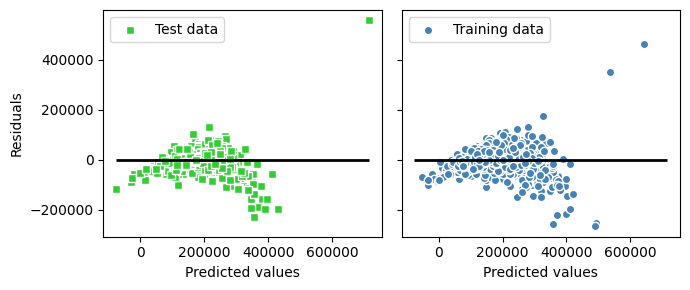

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(y_test_pred, y_test_pred - y_test,
            c='limegreen', marker='s', edgecolor='white',
            label='Test data')

ax2.scatter(y_train_pred, y_train_pred - y_train,
            c='steelblue', marker='o', edgecolor='white',
            label='Training data')

ax1.set_ylabel('Residuals')
for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100,
              color='black', lw=2)

plt.tight_layout()
plt.show()


# computing MSE from the data above

In [ ]:
from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(mse_test)
print(mse_train)

# mae emphasises on the smaller problems more
from sklearn.metrics import mean_absolute_error

mse_train = mean_absolute_error(y_train, y_train_pred)
mse_test = mean_absolute_error(y_test, y_test_pred)
print(mse_test)
print(mse_train)

# therefore based on the mae we can say that modle makes error of appx on train 25000 dollars

1733665198.2213714
1405359023.8968568
26291.633048389358
25275.058190786236


# evaluating r squared
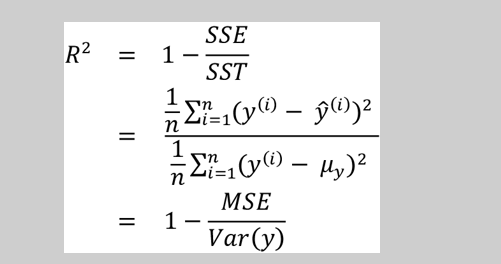

In [ ]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, y_train_pred)

print(r2_train)

r2_test = r2_score(y_test, y_test_pred)

print(r2_test)


# note the model is not that bad however a test r_squared of train seems to be  overfitting slightly

0.7717977560142935
0.7478748927539013
